# **Import Libraries**

In [ ]:
import glob
import os
import zipfile
import shutil
import requests
import gdown
from sklearn.utils import shuffle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, log_loss, roc_curve, auc

# **Compine Datasets**

In [ ]:
# files path
zip_url_1 = "/content/Clean Dataset – Control Group.zip"
zip_url_2 = "/content/Clean Dataset – Parkinson’s Group.zip"


label_col = "Tremor"

base_dir = "/content/csv_merge_work"
extract_dir_1 = os.path.join(base_dir, "group1_extracted")
extract_dir_2 = os.path.join(base_dir, "group2_extracted")
output_dir = os.path.join(base_dir, "output")

for d in [extract_dir_1, extract_dir_2, output_dir]:
    os.makedirs(d, exist_ok=True)

#extract zip files
def extract_zip(zip_path, extract_to):
    if not os.path.exists(zip_path):
        raise FileNotFoundError(f"Not Found: {zip_path}")

    if os.path.exists(extract_to):
        shutil.rmtree(extract_to)
    os.makedirs(extract_to, exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_to)

#read csv and merge them
def load_and_merge_csvs(folder_path, label_value, label_col="label"):
    csv_files = glob.glob(os.path.join(folder_path, "**", "*.csv"), recursive=True)
    csv_files = sorted(csv_files)

    if not csv_files:
        raise ValueError(f"csv not found: {folder_path}")

    dfs = []

    for file_path in csv_files:
        try:
            df = pd.read_csv(file_path)
        except UnicodeDecodeError:
            df = pd.read_csv(file_path, encoding="latin1")
        except Exception as e:
            print(f"file cannot be read: {file_path}")
            print(f"reason: {e}")
            continue

        #add label column
        df[label_col] = label_value

        dfs.append(df)

    if not dfs:
        raise ValueError(f"Failed to read csv {folder_path}")

    merged_df = pd.concat(dfs, ignore_index=True)
    return merged_df, csv_files

#extract zip files
extract_zip(zip_url_1, extract_dir_1)
extract_zip(zip_url_2, extract_dir_2)

#read and merge csv
df_zip1, files1 = load_and_merge_csvs(
    extract_dir_1,
    label_value=0,
    label_col=label_col
)

df_zip2, files2 = load_and_merge_csvs(
    extract_dir_2,
    label_value=1,
    label_col=label_col
)

#merge the two dataframes
final_df = pd.concat([df_zip1, df_zip2], ignore_index=True)

#shuffle dataframe
final_df = final_df.sample(frac=1, random_state=42).reset_index(drop=True)

#save final dataset
final_output = os.path.join(output_dir, "final_shuffled.csv")
final_df.to_csv(final_output, index=False, encoding="utf-8-sig")


final_df.head()

,T,AX,AY,AZ,GX,GY,GZ,Tremor
0,154366,-3.114856,9.983821,6.339846,-0.857343,1.025214,-0.810579,1
1,61774,-2.590526,9.206304,-5.589862,-0.576625,2.049230,-1.244247,0
2,166591,-6.244078,3.473987,4.498705,-0.811511,0.906639,-1.125005,1
3,22636,-4.015076,-1.850718,-6.521805,-0.006395,0.069680,0.120708,1
4,41071,-3.208230,3.835511,-6.009446,-0.021983,0.023715,0.025047,0


# **Load Dataset**

In [ ]:
file_path = "/content/final_shuffled.csv"
df = pd.read_csv(file_path)
df.head()

,T,AX,AY,AZ,GX,GY,GZ,Tremor
0,154366,-3.114856,9.983821,6.339846,-0.857343,1.025214,-0.810579,1
1,61774,-2.590526,9.206304,-5.589862,-0.576625,2.049230,-1.244247,0
2,166591,-6.244078,3.473987,4.498705,-0.811511,0.906639,-1.125005,1
3,22636,-4.015076,-1.850718,-6.521805,-0.006395,0.069680,0.120708,1
4,41071,-3.208230,3.835511,-6.009446,-0.021983,0.023715,0.025047,0


# **Dataset info**

In [ ]:
df.info() #all numeric, no  nulls

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 656131 entries, 0 to 656130
Data columns (total 8 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   T       656131 non-null  int64  
 1   AX      656131 non-null  float64
 2   AY      656131 non-null  float64
 3   AZ      656131 non-null  float64
 4   GX      656131 non-null  float64
 5   GY      656130 non-null  float64
 6   GZ      656130 non-null  float64
 7   Tremor  656131 non-null  int64  
dtypes: float64(6), int64(2)
memory usage: 40.0 MB


In [ ]:
df.isnull().sum()

numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

df.isnull().sum()

,0
T,0
AX,0
AY,0
AZ,0
GX,0
GY,0
GZ,0
Tremor,0


In [ ]:
#remove time column
df = df.drop(columns=["T"])

In [ ]:
df.describe()

,AX,AY,AZ,GX,GY,GZ,Tremor
count,656131.000000,656131.000000,656131.000000,656131.000000,656131.000000,656131.000000,656131.000000
mean,-362.437460,453.419361,-871.292113,-21.204815,6.195526,1.910989,0.490481
std,1581.986547,1696.663032,2866.442095,505.467987,1316.742808,1321.212863,0.499910
min,-32768.000000,-9780.000000,-29776.000000,-12532.000000,-25419.000000,-32768.000000,0.000000
25%,-5.657498,-0.272939,-6.426037,-0.081804,0.000266,-0.016254,0.000000
50%,-4.359841,1.948880,-5.743690,-0.034640,0.015588,0.002798,0.000000
75%,-2.920926,3.883395,-3.330334,-0.012524,0.045565,0.023049,1.000000
max,12476.000000,20300.000000,19.612701,20788.000000,21024.000000,25342.000000,1.000000


In [ ]:
features = ["AX", "AY", "AZ", "GX", "GY", "GZ"]
stats = df.groupby("Tremor")[features].agg(["mean", "max", "min"])
stats_flat = stats.copy()
stats_flat.columns = ['_'.join(col) for col in stats_flat.columns]

stats_flat.reset_index(inplace=True)
stats_flat

,Tremor,AX_mean,AX_max,AX_min,AY_mean,AY_max,AY_min,AZ_mean,AZ_max,AZ_min,GX_mean,GX_max,GX_min,GY_mean,GY_max,GY_min,GZ_mean,GZ_max,GZ_min
0,0,-706.723162,12476.000000,-32768.0000,887.546522,20300.000000,-9780.0000,-1706.233615,19.612701,-29776.0000,-41.559814,20788.000000,-12532.000000,12.121304,21024.000000,-25419.000000,3.738665,25342.000000,-32768.000000
1,1,-4.788784,19.612701,-19.6133,2.442154,19.612701,-19.6133,-3.943507,19.612701,-19.6133,-0.059764,4.365588,-4.365721,0.039748,4.365588,-4.365721,0.012375,4.365588,-4.365721


In [ ]:
corr_matrix = df.corr()
corr_matrix

,AX,AY,AZ,GX,GY,GZ,Tremor
AX,1.000000,-0.609329,0.744502,0.057915,-0.004625,0.014110,0.221812
AY,-0.609329,1.000000,-0.836150,-0.105923,0.002785,0.037311,-0.260790
AZ,0.744502,-0.836150,1.000000,0.136070,-0.025534,0.006727,0.296881
GX,0.057915,-0.105923,0.136070,1.000000,-0.662234,0.639431,0.041044
GY,-0.004625,0.002785,-0.025534,-0.662234,1.000000,-0.945636,-0.004587
GZ,0.014110,0.037311,0.006727,0.639431,-0.945636,1.000000,-0.001410
Tremor,0.221812,-0.260790,0.296881,0.041044,-0.004587,-0.001410,1.000000


# **Data Visualization**

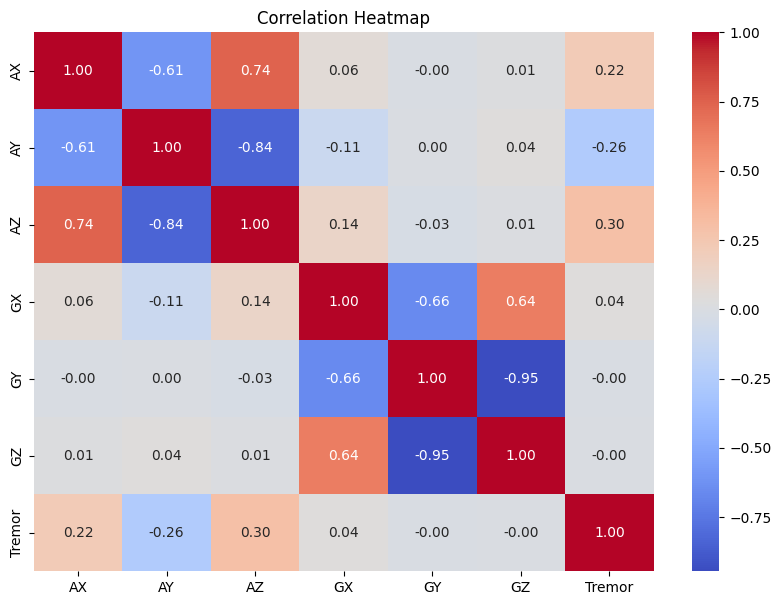

In [ ]:
plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

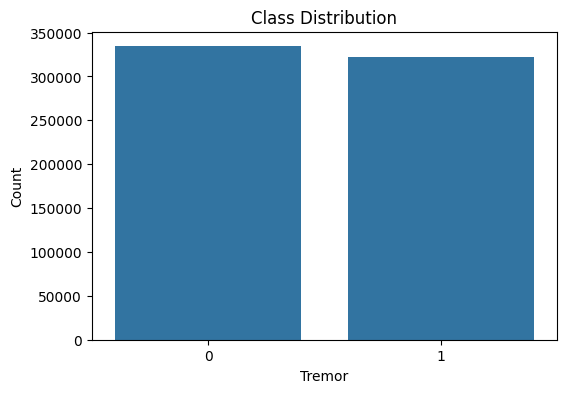

,count
Tremor,
0,334311
1,321820


In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Tremor")
plt.title("Class Distribution")
plt.xlabel("Tremor")
plt.ylabel("Count")
plt.show()

df["Tremor"].value_counts()

# **Prepare Train&Test splits  for model**

In [ ]:
X = df.drop("Tremor", axis=1)
X = X[0:40000]
y = df["Tremor"]
y = y[0:40000]

X.shape, y.shape

((40000, 6), (40000,))

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((28000, 6), (12000, 6), (28000,), (12000,))

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pd.DataFrame(X_train_scaled, columns=X.columns).head()

,AX,AY,AZ,GX,GY,GZ
0,0.226817,-0.267448,0.302928,0.039512,-0.003968,-0.001904
1,0.224624,-0.268131,0.303714,0.039518,-0.003961,-0.001928
2,-2.598319,-0.788626,-4.539833,16.678836,-5.646588,4.787837
3,0.227618,-0.269130,0.302609,0.039477,-0.003961,-0.001910
4,0.226046,-0.267388,0.303090,0.039500,-0.003830,-0.001930


# **Grid Search for Best Hyper parameters for the model**

In [ ]:
rf = RandomForestClassifier(random_state=42)
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring={
        "recall": "recall",
        "precision": "precision"
    },
    refit="recall",
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

model = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best Score: 0.9748812120938926


# **Test the model**

In [ ]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

train_acc, test_acc

(0.99825, 0.9665833333333333)

In [ ]:
print(classification_report(y_test, y_test_pred, target_names=["No Tremor", "Tremor"]))

              precision    recall  f1-score   support

   No Tremor       0.98      0.96      0.97      6105
      Tremor       0.95      0.98      0.97      5895

    accuracy                           0.97     12000
   macro avg       0.97      0.97      0.97     12000
weighted avg       0.97      0.97      0.97     12000



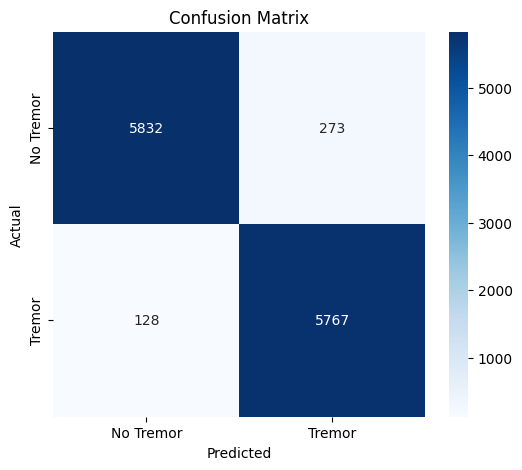

In [ ]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Tremor", "Tremor"], yticklabels=["No Tremor", "Tremor"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# **Store Model**

In [ ]:
joblib.dump(model, "tremor_model.pkl")

['tremor_model.pkl']

# **Test Function**

In [ ]:
def predict_tremor_batch(sensor_list, model = model):
    results = []

    for reading in sensor_list:
        input_df = pd.DataFrame([reading], columns=["AX", "AY", "AZ", "GX", "GY", "GZ"])

        prediction = model.predict(input_df)[0]
        probabilities = model.predict_proba(input_df)[0]

        no_tremor_prob = float(probabilities[0] * 100)
        tremor_prob = float(probabilities[1] * 100)

        result_label = "Tremor" if prediction == 1 else "No Tremor"
        confidence = tremor_prob if prediction == 1 else no_tremor_prob

        results.append({
            "AX": reading[0],
            "AY": reading[1],
            "AZ": reading[2],
            "GX": reading[3],
            "GY": reading[4],
            "GZ": reading[5],
            "Prediction": result_label,
            "Confidence %": round(confidence, 2),
            "No Tremor %": round(no_tremor_prob, 2),
            "Tremor %": round(tremor_prob, 2)
        })

    return pd.DataFrame(results)

# **Import Model**

In [ ]:
model = joblib.load("/content/tremor_model.pkl")

# **Test Input sample**

In [ ]:
sensor_data = [
    [0.907402,-8.767567,6.663063,-0.027446,0.016787,-0.000533],
    [-4924,-1288,-11940,-3728,10504,-10259],
    [-4.838682,-3.282450,-5.781997,-0.047564,0.156014,0.054492],


    [-4.249708,0.186748,-6.698976,0.012657,0.057156,-0.022516],
    [-7.345411,6.964733,4.168305,0.536789,-0.645505,1.701629],
    [7.917625,3.749320,-2.815581,-0.106985,0.049562,-0.048363]
]

result_df = predict_tremor_batch(sensor_data)
result_df

,AX,AY,AZ,GX,GY,GZ,Prediction,Confidence %,No Tremor %,Tremor %
0,0.907402,-8.767567,6.663063,-0.027446,0.016787,-0.000533,No Tremor,100.00,100.00,0.00
1,-4924.000000,-1288.000000,-11940.000000,-3728.000000,10504.000000,-10259.000000,No Tremor,100.00,100.00,0.00
2,-4.838682,-3.282450,-5.781997,-0.047564,0.156014,0.054492,No Tremor,65.08,65.08,34.92
3,-4.249708,0.186748,-6.698976,0.012657,0.057156,-0.022516,Tremor,79.30,20.70,79.30
4,-7.345411,6.964733,4.168305,0.536789,-0.645505,1.701629,Tremor,97.56,2.44,97.56
5,7.917625,3.749320,-2.815581,-0.106985,0.049562,-0.048363,Tremor,79.40,20.60,79.40
